# 04 - XGBoost Model
We train an XGBoost regression model to predict total FPL points for the next season.
We use position-specific models, cross-validation, and SHAP for interpretability.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import joblib
import os

os.makedirs('../models', exist_ok=True)

df = pd.read_csv('../data/processed/features.csv')
print(df.shape)
df.head()

(1519, 75)


,season_name,element_code,start_cost,end_cost,total_points,minutes,goals_scored,assists,clean_sheets,goals_conceded,...,points_per_90_lag2,xg_per_90_lag1,xg_per_90_lag2,xa_per_90_lag1,xa_per_90_lag2,pos_DEF,pos_FWD,pos_GKP,pos_MID,season_num
0,2022/23,154561,45,48,166,3420,0,0,12,46,...,NaN,0.000000,NaN,0.000000,NaN,False,False,True,False,2.0
1,2023/24,154561,50,53,135,2880,0,0,16,24,...,3.958333,0.002895,0.000000,0.003158,0.000000,False,False,True,False,3.0
2,2024/25,154561,55,56,142,3420,0,0,13,34,...,4.368421,0.000000,0.002895,0.001250,0.003158,False,False,True,False,4.0
3,2025/26,154561,55,62,162,3330,0,0,19,26,...,4.218750,0.000000,0.000000,0.000789,0.001250,False,False,True,False,5.0
4,2019/20,109745,55,54,90,2970,0,0,8,47,...,NaN,0.000000,NaN,0.000000,NaN,False,False,True,False,NaN


In [2]:
# Define feature columns and target
feature_cols = [c for c in df.columns if '_lag1' in c or '_lag2' in c] + \
               ['end_price', 'season_num', 'pos_GKP', 'pos_DEF', 'pos_MID', 'pos_FWD']
feature_cols = [c for c in feature_cols if c in df.columns]

target = 'total_points'

# Convert boolean position columns to int
for col in ['pos_GKP', 'pos_DEF', 'pos_MID', 'pos_FWD']:
    if col in df.columns:
        df[col] = df[col].astype(int)

# Drop remaining NaNs
df_clean = df[feature_cols + [target, 'name', 'position', 'season_name']].dropna()
print(f'Clean samples: {len(df_clean)}')
print(f'Features: {len(feature_cols)}')

Clean samples: 900
Features: 24


In [3]:
# Train/test split - use last season as test
train = df_clean[df_clean['season_name'] != '2025/26']
test  = df_clean[df_clean['season_name'] == '2025/26']

X_train = train[feature_cols]
y_train = train[target]
X_test  = test[feature_cols]
y_test  = test[target]

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (611, 24), Test: (289, 24)


In [4]:
# Train XGBoost model
xgb = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbosity=0
)

xgb.fit(X_train, y_train)

# Cross validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb, X_train, y_train, cv=kf, scoring='r2')
print(f'CV R2 scores: {cv_scores.round(3)}')
print(f'Mean CV R2: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})')

CV R2 scores: [0.383 0.457 0.367 0.359 0.37 ]
Mean CV R2: 0.387 (+/- 0.036)


In [5]:
# Evaluate on test set
y_pred = xgb.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2   = r2_score(y_test, y_pred)

print(f'Test MAE:  {mae:.2f} points')
print(f'Test RMSE: {rmse:.2f} points')
print(f'Test R2:   {r2:.3f}')

# Actual vs Predicted plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Points')
plt.ylabel('Predicted Points')
plt.title(f'XGBoost: Actual vs Predicted (R2={r2:.3f})')
plt.tight_layout()
plt.savefig('../data/processed/xgb_actual_vs_predicted.png', dpi=150)
plt.show()

Test MAE:  35.50 points
Test RMSE: 45.05 points
Test R2:   0.300


<Figure size 800x600 with 1 Axes>

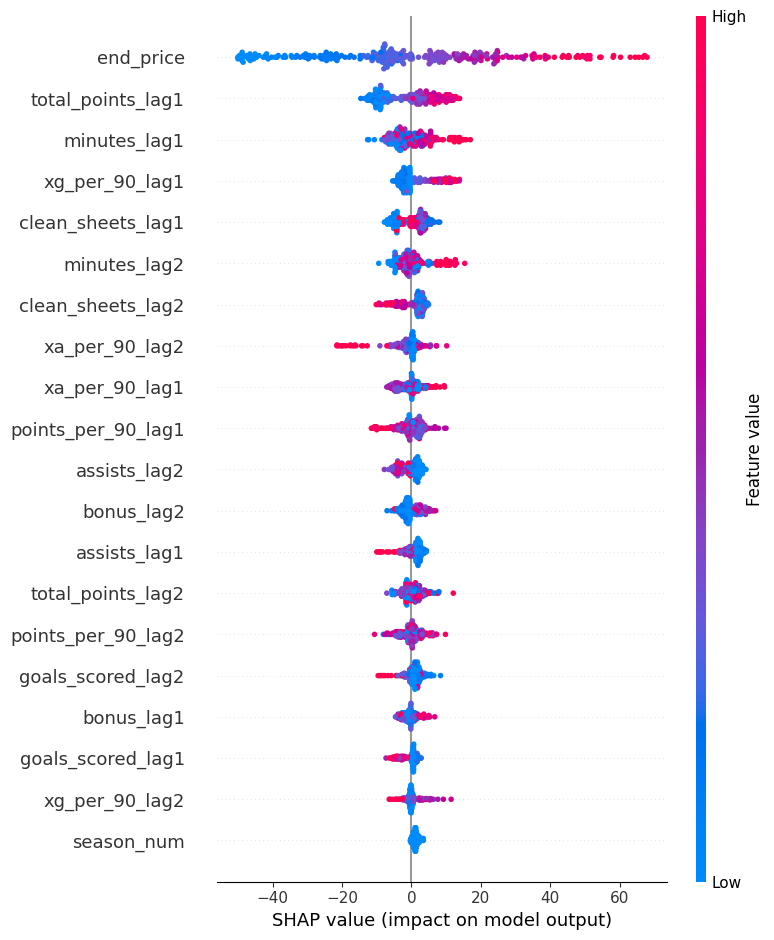

SHAP plot saved.


In [6]:
# SHAP feature importance
explainer = shap.Explainer(xgb)
shap_values = explainer(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig('../data/processed/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('SHAP plot saved.')

In [7]:
# Save model and predictions
joblib.dump(xgb, '../models/xgb_fpl.pkl')

results = test[['name','position','season_name']].copy()
results['actual_points'] = y_test.values
results['predicted_points'] = y_pred
results['error'] = results['actual_points'] - results['predicted_points']
results = results.sort_values('predicted_points', ascending=False)
results.to_csv('../data/processed/xgb_predictions.csv', index=False)

print('Model saved to ../models/xgb_fpl.pkl')
print('\nTop 10 predicted players:')
results.head(10)

Model saved to ../models/xgb_fpl.pkl

Top 10 predicted players:


,name,position,season_name,actual_points,predicted_points,error
323,Schade,MID,2025/26,125,165.618225,-40.618225
3,Raya,GKP,2025/26,162,160.452942,1.547058
214,Watkins,FWD,2025/26,167,157.442719,9.557281
1059,Semenyo,MID,2025/26,202,154.117096,47.882904
1159,Mbeumo,MID,2025/26,148,153.092957,-5.092957
679,Ndiaye,MID,2025/26,128,150.984024,-22.984024
1155,B.Fernandes,MID,2025/26,235,149.221985,85.778015
1183,Amad,MID,2025/26,91,149.219315,-58.219315
1094,Haaland,FWD,2025/26,239,148.177719,90.822281
978,Gakpo,MID,2025/26,131,147.339767,-16.339767
